# ⚙️ Stock Price Predictor - Data Preprocessing
### Preparing data for Machine Learning model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load the data we saved in Phase 2
df = pd.read_csv("../data/processed/AAPL_explored.csv", index_col=0)
df.index = pd.to_datetime(df.index)

print("✅ Data loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

✅ Data loaded!
Shape: (2514, 9)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_50', 'MA_200', 'Year', 'Daily_Range']


,Close,High,Low,Open,Volume,MA_50,MA_200,Year,Daily_Range
2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000.0,NaN,NaN,2015,0.716948
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400.0,NaN,NaN,2015,0.619586
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600.0,NaN,NaN,2015,0.331921
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000.0,NaN,NaN,2015,0.763419
2015-01-09,24.785633,25.060020,24.387327,24.931677,214798000.0,NaN,NaN,2015,0.672693


In [3]:
# Check how many NaN values we have
print("Missing values BEFORE:")
print(df.isnull().sum())

# Drop rows where MA_50 or MA_200 is NaN
# We can't use these rows for training — they have incomplete features
df = df.dropna()

print("\nMissing values AFTER:")
print(df.isnull().sum())
print("\nNew shape:", df.shape)
print("Rows removed:", 2514 - df.shape[0])

Missing values BEFORE:
Close            0
High             0
Low              0
Open             0
Volume           0
MA_50           49
MA_200         199
Year             0
Daily_Range      0
dtype: int64

Missing values AFTER:
Close          0
High           0
Low            0
Open           0
Volume         0
MA_50          0
MA_200         0
Year           0
Daily_Range    0
dtype: int64

New shape: (2315, 9)
Rows removed: 199


In [4]:
# X = inputs we give the model (features)
# y = what we want the model to predict (target)

# Features — everything the model will LEARN FROM
feature_columns = ['Open', 'High', 'Low', 'Volume', 
                   'MA_50', 'MA_200', 'Daily_Range']

X = df[feature_columns]

# Target — what we want to PREDICT (next day's close price)
y = df['Close']

print("✅ Features (X) shape:", X.shape)
print("✅ Target (y) shape:", y.shape)
print("\nFeature columns:", feature_columns)

✅ Features (X) shape: (2315, 7)
✅ Target (y) shape: (2315,)

Feature columns: ['Open', 'High', 'Low', 'Volume', 'MA_50', 'MA_200', 'Daily_Range']


In [5]:
# ML models work MUCH better when all numbers are in same range (0 to 1)
# Example: Volume is 200,000,000 but Price is 150 — huge difference!
# Scaling brings everything to 0-1 range

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data scaled!")
print("Before scaling - Volume max:", X['Volume'].max())
print("After scaling - max value:", X_scaled.max())
print("After scaling - min value:", X_scaled.min())

✅ Data scaled!
Before scaling - Volume max: 533478800.0
After scaling - max value: 1.0000000000000002
After scaling - min value: 0.0


In [6]:
from sklearn.model_selection import train_test_split

# 80% data for training, 20% for testing
# test_size=0.2 means 20% goes to testing
# random_state=42 means same split every time we run

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print(f"\nModel will LEARN from {X_train.shape[0]} days")
print(f"Model will be TESTED on {X_test.shape[0]} days")

✅ Data split done!
Training samples: 1852
Testing samples: 463

Model will LEARN from 1852 days
Model will be TESTED on 463 days


In [7]:
import pickle

# Save the scaler — we need it later to scale new data for predictions
os.makedirs("../models", exist_ok=True)
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save final processed data
df.to_csv("../data/processed/AAPL_final.csv")

print("✅ Scaler saved to models/scaler.pkl")
print("✅ Final data saved to data/processed/AAPL_final.csv")
print(f"\nFinal dataset shape: {df.shape}")
print("Phase 3 - Preprocessing COMPLETE! ✅")

✅ Scaler saved to models/scaler.pkl
✅ Final data saved to data/processed/AAPL_final.csv

Final dataset shape: (2315, 9)
Phase 3 - Preprocessing COMPLETE! ✅


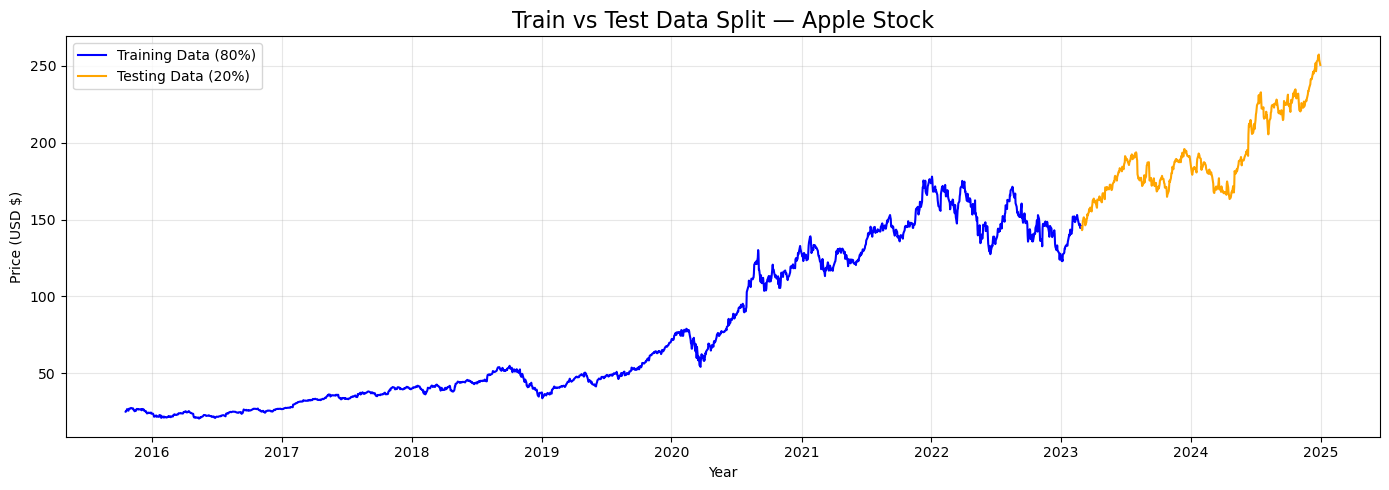

Training period: 2015-10-19 to 2023-02-28
Testing period:  2023-02-28 to 2024-12-30


In [8]:
%matplotlib inline
plt.figure(figsize=(14,5))

# Show which part of data is training and which is testing
train_size = int(len(df) * 0.8)
plt.plot(df.index[:train_size], df['Close'][:train_size], 
         color='blue', label='Training Data (80%)')
plt.plot(df.index[train_size:], df['Close'][train_size:], 
         color='orange', label='Testing Data (20%)')

plt.title('Train vs Test Data Split — Apple Stock', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training period: {df.index[0].date()} to {df.index[train_size].date()}")
print(f"Testing period:  {df.index[train_size].date()} to {df.index[-1].date()}")